CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)
Using device: cuda:0


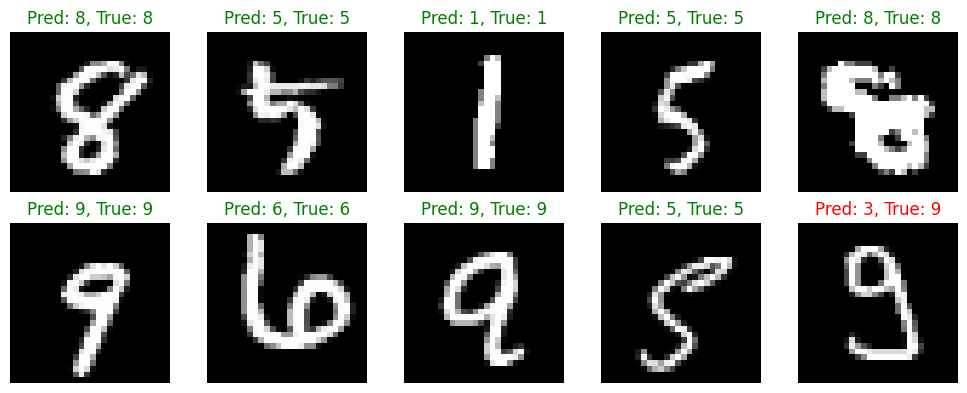

In [1]:
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

batch_size = 60
train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):


       super(CNN, self).__init__()

       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)
    
    def forward(self, x):

       x = F.relu(self.conv1(x))  
       x = self.pool(x)           
       x = F.relu(self.conv2(x))  
       x = self.pool(x)           
       x = x.reshape(x.shape[0], -1)  
       x = self.fc1(x)            
       return x

loaded_model = CNN(in_channels=1, num_classes=10)

loaded_model.load_state_dict(torch.load('MNISTmodel.pth'))
print(loaded_model)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
loaded_model.to(device)


def show_predictions(images, labels, preds):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].cpu().reshape(28, 28), cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        axes[i].set_title(f"Pred: {preds[i]}, True: {labels[i]}", color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = loaded_model(images)
_, preds = torch.max(outputs, 1)

show_predictions(images[:10], labels[:10], preds[:10])